In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
tags_df=pd.read_csv("./ml-32m/tags.csv")

In [ ]:
tags_df.shape

(2000072, 4)

In [ ]:
tags_df.head(10)

,userId,movieId,tag,timestamp
0,22,26479,Kevin Kline,1583038886
1,22,79592,misogyny,1581476297
2,22,247150,acrophobia,1622483469
3,34,2174,music,1249808064
4,34,2174,weird,1249808102
5,34,8623,Steve Martin,1249808497
6,55,5766,the killls and the score,1319322078
7,58,7451,bullying,1672551536
8,58,7451,clique,1672551510
9,58,7451,coming of age,1672551502


In [ ]:

tags_df["tag"]=tags_df["tag"].astype(str).str.lower().str.strip()
tags_df["tag"]=tags_df["tag"].astype(str).str.strip().str.replace(" ","-")
tags_list = tags_df["tag"].drop_duplicates()
tags_list


0                         kevin-kline
1                            misogyny
2                          acrophobia
3                               music
4                               weird
                      ...            
1999767                   max-riemelt
1999804    grã©goire-leprince-ringuet
1999877                   laura-neiva
1999925                        pemble
1999930                clemence-poesy
Name: tag, Length: 131014, dtype: str

In [ ]:
#tags_frequency={}
#for tag in tags_list.tolist():
#    tags_frequency[tag]=0

#for tag in tags_df["tag"].tolist():
#    tags_frequency[tag]+=1
    
# tags_df["tag"].value-count

#tags_frequency=pd.Series(tags_frequency)
#tags_frequency.sort_values().plot(kind="bar")

tags_frequency=tags_df["tag"].value_counts().sort_values(ascending=False)


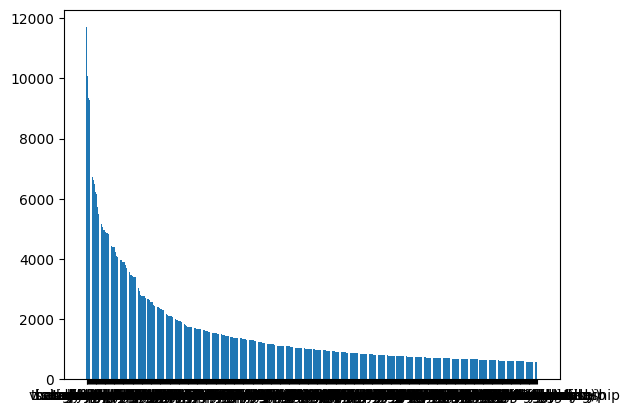

In [ ]:
#plt.bar(tags_frequency.index[:500],tags_frequency.values[:500])
#plt.show()



In [ ]:
print(tags_frequency.index[:10])
print(tags_frequency.values[:10])

tags_frequency=tags_frequency.head(5000) # top 5000 movie tags
list_of_tags=tags_frequency.sort_index

def createIDF():
    N = len(tags_frequency)

    df_count = np.zeros(len(list_of_tags))
    for i, tag in enumerate(list_of_tags):

        # Same as below
        sum = 0
        for tags in tags_frequency.indexes:
            sum += tag in tags
        df_count[i] = sum

        # Same as above
        df_count[i] = tags_df["tags"].apply(lambda gs: tag in gs).sum()

    # Inverse of Data Frequency
        idf = np.log(N / (df_count + 1))
        return idf

idf_vectors=(createIDF())

def createVector(tags):
    vector=np.zeros(len(list_of_tags))
    for i in range(0,len(list_of_tags)):
        vector[i]=int(list_of_tags[i] in tags)
    return np.array(vector)

def create_tfidf_vector(tags):
    onehot = createVector(tags)
    tf = onehot / len(tags)
    return tf * idf_vectors


movie_tags_df=tags_df.groupby("movieId")["tag"].apply(list)
movie_tags_df["tf_idf"]=create_tfidf_vector(movie_tags_df["tag"])



Index(['sci-fi', 'atmospheric', 'action', 'comedy', 'funny', 'surreal',
       'visually-appealing', 'based-on-a-book', 'twist-ending',
       'thought-provoking'],
      dtype='str', name='tag')
[11700 10088  9344  9275  8088  7480  7253  6733  6613  6490]
